In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder

In [2]:
df = pd.read_excel("final.xlsx", sheet_name="Sheet1")
df.shape

(50000, 11)

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    50000 non-null  int64 
 1   marital_status         50000 non-null  object
 2   number_of_dependants   50000 non-null  int64 
 3   bmi_category           50000 non-null  object
 4   smoking_status         50000 non-null  object
 5   employment_status      50000 non-null  object
 6   income_level           50000 non-null  object
 7   income_lakhs           50000 non-null  int64 
 8   insurance_plan         50000 non-null  object
 9   annual_premium_amount  50000 non-null  int64 
 10  n_disease              50000 non-null  int64 
dtypes: int64(5), object(6)
memory usage: 4.2+ MB


## 1

Linear Regression

scaling: 0/1 |  encoding: OHE

In [5]:
y = df['annual_premium_amount'].copy()
x = df.drop(['annual_premium_amount'], axis = 1)

In [6]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=2)

In [119]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((37500, 10), (12500, 10), (37500,), (12500,))

In [83]:
# Columns to scale to 0-1
num_cols = [
    "age",
    # "income_lakhs",
    "n_disease",
    # "number_of_dependants"
]

# All remaining columns → One-Hot Encoding
cat_cols = [
    "marital_status",
    "bmi_category",
    "smoking_status",
    "employment_status",
    "income_level",
    "insurance_plan"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop = "first"), cat_cols),
        # ("drop", "drop", ['marital_status'])
    ]
)

In [84]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['age', 'n_disease']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['marital_status',
                                                   'bmi_category',
                                                   'smoking_status',
                                                   'employment_status',
                                                   'income_level',
                                                   'insurance_plan'])])),
                ('regressor', LinearRegression())])

In [85]:
# r2 score
model.score(x_test, y_test)

0.9294881840558562

weights interpretation

In [87]:
f = model.named_steps["preprocessor"].get_feature_names_out()
w = model.named_steps["regressor"].coef_

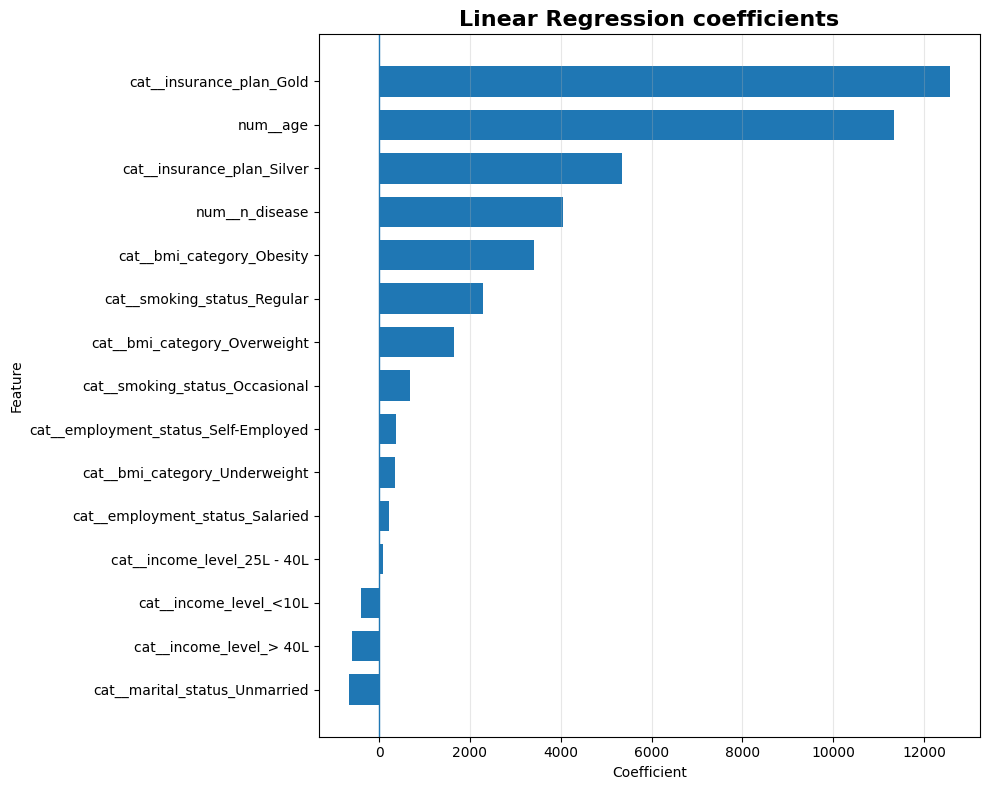

In [88]:
# Create DataFrame
coef_df = pd.DataFrame({
    "Feature": f,
    "Coefficient": w
})

# Sort coefficients
coef_df = coef_df.sort_values("Coefficient")

# Plot
plt.figure(figsize=(10, 8))

plt.barh(
    coef_df["Feature"],
    coef_df["Coefficient"],
    height=0.7
)

# Zero reference line
plt.axvline(0, linewidth=1)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Linear Regression coefficients", fontsize=16, fontweight="bold")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

NOD -> -ve relation, which is somwhat opposite then what we saw by EDA

Let's see if it has any correlation with other independent variables. 

In [24]:
sub = x[['marital_status', 'number_of_dependants']].copy()

In [26]:
sub['marital_status_int'] = sub['marital_status'].map({'Unmarried': 0, "Married": 1})

In [29]:
sub[['marital_status_int', 'number_of_dependants']].corr()

,marital_status_int,number_of_dependants
marital_status_int,1.000000,0.842653
number_of_dependants,0.842653,1.000000


So, Marital status and number of dependents are highly correlated. 

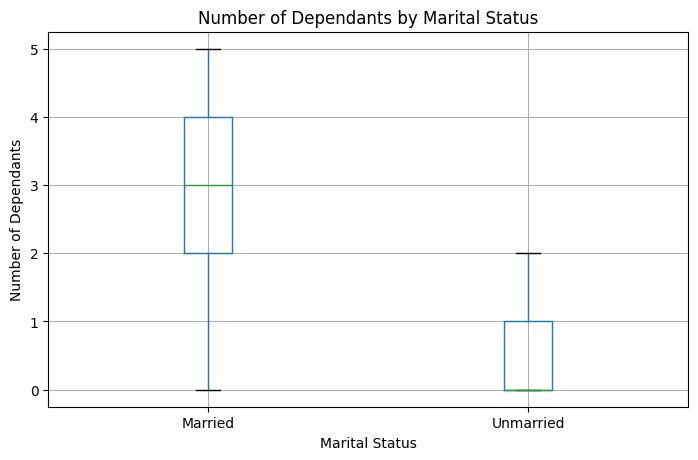

In [36]:
sub.boxplot(
    column='number_of_dependants',
    by='marital_status',
    figsize=(8, 5)
)

plt.xlabel("Marital Status")
plt.ylabel("Number of Dependants")
plt.title("Number of Dependants by Marital Status")

plt.suptitle("")  # removes pandas' automatic title
plt.show()

In [70]:
for a,b in zip(f,w):
    print(a,b)

num__age 11658.670731243512
num__income_lakhs -611.0063996339904
num__n_disease 4156.585829568376
num__number_of_dependants 610.4030910236942
cat__bmi_category_Obesity 3414.8847232792064
cat__bmi_category_Overweight 1648.101478772593
cat__bmi_category_Underweight 343.02062139023633
cat__smoking_status_Occasional 703.90389992578
cat__smoking_status_Regular 2295.158439052788
cat__employment_status_Salaried 242.55330776258972
cat__employment_status_Self-Employed 391.10677181128403
cat__income_level_25L - 40L 176.7826543569021
cat__income_level_<10L -468.2464959865008
cat__income_level_> 40L -307.17497261659173
cat__insurance_plan_Gold 12597.133861519054
cat__insurance_plan_Silver 5378.066392700595


Now the NOD weight is giving correct interpretation. 

Let's try regularization

In [ ]:
# l2 reg

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha = 0.3))
])

model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['age', 'income_lakhs',
                                                   'n_disease',
                                                   'number_of_dependants']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['marital_status',
                                                   'bmi_category',
                                                   'smoking_status',
                                                   'employment_status',
                                                   'income_level',
                                                   'insurance_plan'])])),
                ('regressor', Ridge(alpha=0.3))])

In [111]:
# r2 score
model.score(x_test, y_test)

0.9295493547280944

In [112]:
f = model.named_steps["preprocessor"].get_feature_names_out()
w = model.named_steps["regressor"].coef_

for a,b in zip(f,w):
    print(a,b)

num__age 11282.43230685338
num__income_lakhs -606.5927873982971
num__n_disease 4055.1496548691116
num__number_of_dependants -545.4013002006466
cat__marital_status_Unmarried -949.1000584603511
cat__bmi_category_Obesity 3417.864604876657
cat__bmi_category_Overweight 1648.1123191434674
cat__bmi_category_Underweight 330.00669325854017
cat__smoking_status_Occasional 696.4315220916452
cat__smoking_status_Regular 2287.7526903620164
cat__employment_status_Salaried 228.22347965997406
cat__employment_status_Self-Employed 369.5068552814828
cat__income_level_25L - 40L 175.32331528001757
cat__income_level_<10L -474.3371055231739
cat__income_level_> 40L -307.4626256951476
cat__insurance_plan_Gold 12584.686832913492
cat__insurance_plan_Silver 5364.09399029215


In [121]:
# l1 reg

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Lasso(alpha = 10))
])

model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['age', 'income_lakhs',
                                                   'n_disease',
                                                   'number_of_dependants']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['marital_status',
                                                   'bmi_category',
                                                   'smoking_status',
                                                   'employment_status',
                                                   'income_level',
                                                   'insurance_plan'])])),
                ('regressor', Lasso(alpha=10))])

In [122]:
# r2 score
model.score(x_test, y_test)

0.929250024252921

In [123]:
f = model.named_steps["preprocessor"].get_feature_names_out()
w = model.named_steps["regressor"].coef_

for a,b in zip(f,w):
    print(a,b)

num__age 11300.40414773427
num__income_lakhs -0.0
num__n_disease 4012.719708218342
num__number_of_dependants -0.0
cat__marital_status_Unmarried -702.5535461366104
cat__bmi_category_Obesity 3301.291220958665
cat__bmi_category_Overweight 1558.5195046531546
cat__bmi_category_Underweight 202.31752934778822
cat__smoking_status_Occasional 594.1254176886287
cat__smoking_status_Regular 2229.8017931947243
cat__employment_status_Salaried 150.88523205608348
cat__employment_status_Self-Employed 305.50666645904903
cat__income_level_25L - 40L 68.62319178612445
cat__income_level_<10L -364.642874109756
cat__income_level_> 40L -484.3188457217714
cat__insurance_plan_Gold 12494.023637843895
cat__insurance_plan_Silver 5292.376969754431


these 0 weights in lasso model tells that income lakhs and NOD are less important